## A4

Bellotto Simone, Cattaneo Augusto, Hemalatha Thirumal Manasa , Leckebusch Jens, Rider Benjamin

In [40]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import math

### Initialization

In [ ]:
# Weibull parameters
WEIBULL_PARAMS = {
    "rotor":     {"shape": 3, "scale": 3000},
    "bearing":   {"shape": 2, "scale": 3750},
    "gearbox":   {"shape": 3, "scale": 2400},
    "generator": {"shape": 2, "scale": 3300}
}
#Finds MTTF and appends it to the weibull params dictionary
for comp, params in WEIBULL_PARAMS.items():
    shape = params["shape"]
    scale = params["scale"]
    params["MTTF"] = scale * math.gamma(1 + 1/shape)

# Costs
C_FIXED = 50   # per maintenance cycle (example)
C_ACCESS = 10  # turbine-to-turbine cost

# Replacement costs
C1 = {"rotor": 112, "bearing": 60, "gearbox": 152, "generator": 100}
C2 = {"rotor": 28,  "bearing": 15, "gearbox": 38,  "generator": 25}

# Age reduction
AGE_REDUCTION = {
    "minor": 0.30,
    "major": 0.50
}

# Condition-based thresholds (for CBM)
MAX_AGE = 0.95
MED_AGE = 0.70
MIN_AGE = 0.50

# Turbines
N_TURBINES = 50
COMPONENTS = ["rotor", "bearing", "gearbox", "generator"]
    
# N of Monte Carlo iterations (min 500)
ITER = 1000

# Seed
np.random.seed(42)

# Number of cycles to simulate
N_CYCLES = 10

In [4]:
# sample failure age (similar to matlab wblrnd)
def sample_failure_age(component):
    shape = WEIBULL_PARAMS[component]["shape"]
    scale = WEIBULL_PARAMS[component]["scale"]
    return np.random.weibull(shape) * scale

# create windfarm
def init_windfarm():
    """
    Initialize 50 turbines × 4 components.
    """
    farm = []
    for _ in range(N_TURBINES):
        turbine = {}
        for comp in COMPONENTS:
            turbine[comp] = {
                "virtual_age": 0.0,
                "failure_age": sample_failure_age(comp)
            }
        farm.append(turbine)
    return farm

### Plot functions

In [5]:
def plot_amc_stabilization(all_AMC, strategy_name, title="AMC Stabilization Curve", figsize=(7,4)):
    # running avg
    running_avg_amc = np.cumsum(all_AMC) / np.arange(1, len(all_AMC) + 1)
    # total avg
    final_avg = np.mean(all_AMC)

    plt.figure(figsize=figsize)
    plt.plot(running_avg_amc, lw=1.8, label="Running average AMC")
    plt.axhline(final_avg, color='r', linestyle='--', linewidth=1.5,
                label=f"Final average AMC = {final_avg:.2f}")
    #plt.title(title)
    plt.xlabel("Monte Carlo iteration")
    plt.ylabel("Average AMC (EUR K/year)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig_amc_" + strategy_name + ".png")
    plt.show()
    
def plot_coefficient_of_variation(all_AMC, strategy_name, title="Coefficient of Variation Convergence", figsize=(7,4)):
    """
    Plot the running coefficient of variation (CV) of AMC values to assess Monte Carlo convergence.
    CV = running standard deviation / running mean.
    """

    # running avg / mean
    running_mean = np.cumsum(all_AMC) / np.arange(1, len(all_AMC) + 1)

    # running var
    running_var = (np.cumsum((all_AMC - running_mean)**2)) / np.arange(1, len(all_AMC) + 1)
    running_std = np.sqrt(running_var)

    # running coefficient of variation
    running_cv = running_std / running_mean

    plt.figure(figsize=figsize)
    plt.plot(running_cv, lw=1.8, label="Running CV")
    plt.axhline(running_cv[-1], color='r', linestyle='--', linewidth=1.3,
                label=f"Final CV = {running_cv[-1]:.4f}")
    #plt.title(title)
    plt.xlabel("Monte Carlo iteration")
    plt.ylabel("Coefficient of Variation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig_ac_" + strategy_name + ".png")
    plt.show()

### Analysis functions

In [14]:
def run_simple_montecarlo(strategy_function): #initialize 
    all_AMC = [] 
    all_total_cost = [] 
    all_total_days = [] 
    all_fail_counts = [] 
    all_minor_counts = [] 
    all_major_counts = [] 
    #montecarlo 
    for i in range(ITER): 
        strategy_name, total_cost_10, total_days_10, AMC_10, failure_counts, minor_counts, major_counts = strategy_function() 
        all_total_cost.append(total_cost_10) 
        all_total_days.append(total_days_10) 
        all_AMC.append(AMC_10) 
        all_fail_counts.append(failure_counts) 
        all_minor_counts.append(minor_counts) 
        all_major_counts.append(major_counts) 
        #aggregate 
        avg_AMC = float(np.mean(all_AMC)) 
        std_AMC = float(np.std(all_AMC, ddof=1)) 
        avg_total_cost = float(np.mean(all_total_cost)) 
        avg_total_days = float(np.mean(all_total_days)) 
        avg_failures = { comp: float(np.mean([fc[comp] for fc in all_fail_counts])) for comp in COMPONENTS } 
        avg_minors = { comp: float(np.mean([fc[comp] for fc in all_minor_counts])) for comp in COMPONENTS } 
        avg_majors = { comp: float(np.mean([fc[comp] for fc in all_major_counts])) for comp in COMPONENTS } 
    print("============================================================") 
    print(strategy_name) 
    print("============================================================") 
    print(f"Iterations: {ITER}, Cycles per iteration: {N_CYCLES}, Turbines: {N_TURBINES}") 
    print(f"Average total cost over 10 cycles: {avg_total_cost:.2f} EUR $") 
    print(f"Average total elapsed days for 10 cycles: {avg_total_days:.1f} days") 
    print(f"Average AMC (per formula): {avg_AMC:.2f} K EUR/year (std: {std_AMC:.2f})") 
    print("\nAverage number of failure replacements over 10 cycles (by component):") 
    for comp, val in avg_failures.items(): 
        print(f" {comp:9s}: {val:.3f}")
    print("\nAverage number of minor repairs over 10 cycles (by component):") 
    for comp, val in avg_minors.items(): 
        print(f" {comp:9s}: {val:.3f}") 
    print("\nAverage number of major repairs over 10 cycles (by component):") 
    for comp, val in avg_majors.items(): 
        print(f" {comp:9s}: {val:.3f}") 
    plot_amc_stabilization(all_AMC, "s1", title="AMC Stabilization Curve", figsize=(7,4)) 
    plot_coefficient_of_variation(all_AMC, "s1", title="Coefficient of Variation Convergence", figsize=(7,4))

### Assignment

#### Strategy 1

In [9]:
# Strategy 1 - implementation
def simulate_S1():
    #initialize
    strategy_name = "CORRECTIVE MAINTENANCE (CM)"
    farm = init_windfarm()
    total_cost = 0.0
    total_days = 0.0
    failure_counts = {c: 0 for c in COMPONENTS}
    minor_counts = {c: 0 for c in COMPONENTS}
    major_counts = {c: 0 for c in COMPONENTS}
    
    # Run cycles
    for c in range(N_CYCLES):
        min_residual = np.inf
        failed_turbine_idx = None
        failed_component = None
        
        for ti in range(N_TURBINES):
            for comp in COMPONENTS:
                comp_state = farm[ti][comp]
                residual = comp_state["failure_age"] - comp_state["virtual_age"]
                if residual < min_residual:
                    min_residual = residual
                    failed_turbine_idx = ti
                    failed_component = comp
        
        #find time to next component failure
        dt = max(min_residual, 0.0)
        total_days += dt
            
        for ti in range(N_TURBINES):
            for comp in COMPONENTS:
                farm[ti][comp]["virtual_age"] += dt
                
        #costs # TODO: check if correct
        cycle_cost = C_FIXED
        cycle_cost += C_ACCESS  # TODO: check if correct
        cycle_cost += C1[failed_component]  # corrective replacement

        total_cost += cycle_cost
        failure_counts[failed_component] += 1

        # replace component
        farm[failed_turbine_idx][failed_component]["virtual_age"] = 0.0
        farm[failed_turbine_idx][failed_component]["failure_age"] = sample_failure_age(failed_component)
        
        AMC = total_cost / total_days * 365.0
        
    return strategy_name, total_cost, total_days, AMC, failure_counts, minor_counts, major_counts

CORRECTIVE MAINTENANCE (CM)
Iterations: 1000, Cycles per iteration: 10, Turbines: 50
Average total cost over 10 cycles: 1639.02 EUR $
Average total elapsed days for 10 cycles: 875.9 days
Average AMC (per formula): 694.80 K EUR/year (std: 99.96)

Average number of failure replacements over 10 cycles (by component):
 rotor    : 1.263
 bearing  : 2.695
 gearbox  : 2.532
 generator: 3.510

Average number of minor repairs over 10 cycles (by component):
 rotor    : 1.263
 bearing  : 2.695
 gearbox  : 2.532
 generator: 3.510

Average number of major repairs over 10 cycles (by component):
 rotor    : 1.263
 bearing  : 2.695
 gearbox  : 2.532
 generator: 3.510


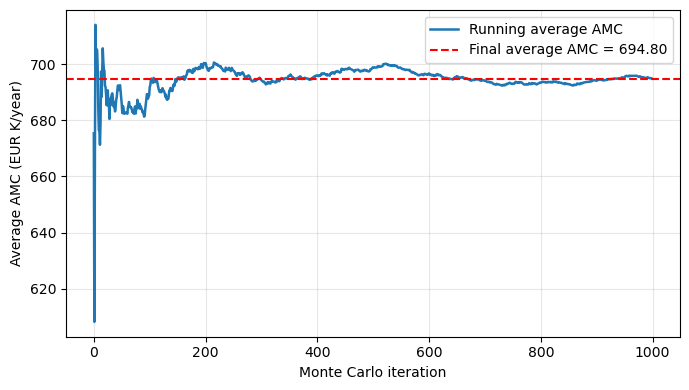

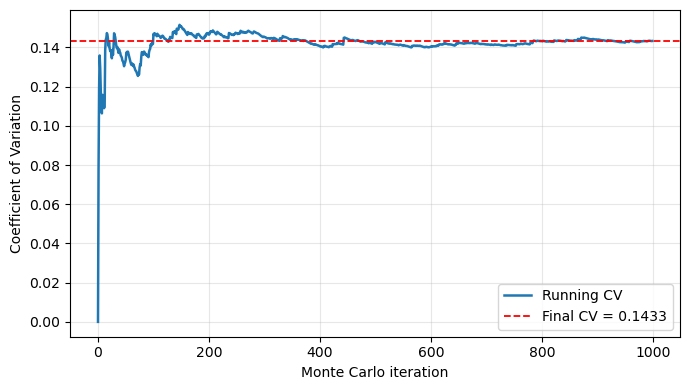

In [12]:
# Strategy 1 - execution
run_simple_montecarlo(simulate_S1)

#### Strategy 1 ALT

CORRECTIVE MAINTENANCE (CM)
Iterations: 1000, Cycles per iteration: 10, Turbines: 50
Average total cost over 10 cycles: 37497.70 EUR $
Average total elapsed days for 10 cycles: 4028.0 days
Average AMC (per formula): 3397.88 K EUR/year (std: 136.60)

Average number of failure replacements over 10 cycles (by component):
 rotor    : 54.131
 bearing  : 41.581
 gearbox  : 71.631
 generator: 50.073

Average number of minor repairs over 10 cycles (by component):
 rotor    : 0.000
 bearing  : 0.000
 gearbox  : 0.000
 generator: 0.000

Average number of major repairs over 10 cycles (by component):
 rotor    : 0.000
 bearing  : 0.000
 gearbox  : 0.000
 generator: 0.000


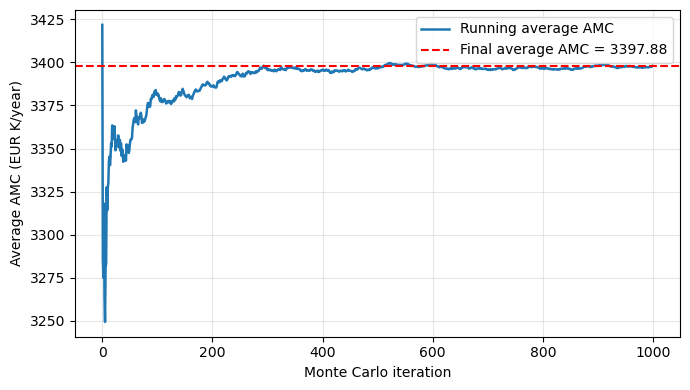

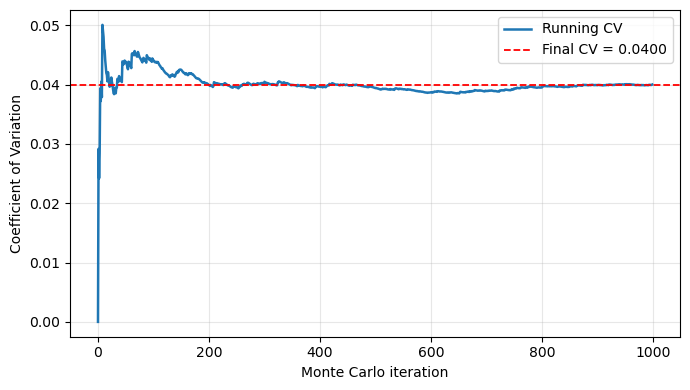

In [ ]:
# --- Simulation classes ---
class Component:
    def __init__(self, name, id, age=0):
        self.name = name
        self.id = id
        self.age = age
        self.replaced = False
        self.shape = WEIBULL_PARAMS[name]['shape']
        self.scale = WEIBULL_PARAMS[name]['scale']
        self.failtime = np.random.weibull(self.shape) * self.scale

    def replace(self, day, replacements):
        self.age = 0
        self.failtime = day + np.random.weibull(self.shape) * self.scale
        self.replaced = True
        replacements[self.name] += 1

    def minor_repair(self, day, minor_counts):
        self.age *= (1 - AGE_REDUCTION["minor"])
        u = np.random.random()
        remaining = (self.age**self.shape - (self.scale**self.shape) * np.log(u))**(1/self.shape) - self.age
        self.failtime = day + remaining
        minor_counts[self.name] += 1

    def major_repair(self, day, major_counts):
        self.age *= (1 - AGE_REDUCTION["major"])
        u = np.random.random()
        remaining = (self.age**self.shape - (self.scale**self.shape) * np.log(u))**(1/self.shape) - self.age
        self.failtime = day + remaining
        major_counts[self.name] += 1

class Turbine:
    def __init__(self, id):
        self.id = id
        self.components = [Component(name, id) for name in COMPONENTS]

# --- Strategy function ---
def strategy1(cycle_length):
    strategy_name = "CORRECTIVE MAINTENANCE (CM)"

    turbines = [Turbine(i) for i in range(N_TURBINES)]
    all_components = [comp for turb in turbines for comp in turb.components]  # flat list
        

    minor_counts = {c: 0 for c in COMPONENTS}
    major_counts = {c: 0 for c in COMPONENTS}
    replacements = {c: 0 for c in COMPONENTS}
    day = 0
    total_cost = 0

    # Advance to first event
    next_failure = min(comp.failtime for comp in all_components) if all_components else float("inf")
    day = next_failure

    for comp in all_components:
        comp.age += day

    while day <= (N_CYCLES+1) * cycle_length:
        daily_cost = 0
        maintenance = False
        serviced_turbines = set()
        while day >= next_failure:
            # Handle failure events
            for comp in all_components:
                if abs(comp.failtime - day) < 1e-6:  # handle float rounding
                    maintenance = True
                    serviced_turbines.add(comp.id)
                    daily_cost += comp.replace(day, replacements)
            next_failure = min(comp.failtime for comp in all_components) if all_components else float("inf")

        # Add fixed costs
        daily_cost += maintenance * C_FIXED
        daily_cost += len(serviced_turbines) * C_ACCESS
        total_cost += daily_cost

        # Jump to next event
        next_day = next_failure
        delta = next_day - day
        if delta <= 0:
            delta = 1e-6  # avoid zero increment
        day = next_day

        # Update component ages
        for comp in all_components:
            comp.age += delta

    AMC = total_cost / day * 365

    return strategy_name, total_cost, day, AMC, replacements, minor_counts, major_counts

# Run Monte Carlo
run_simple_montecarlo(lambda: strategy1(365))

#### Strategy 2

TIME-BASED MAINTENANCE (TBM) EVERY 12 MONTHS
Iterations: 1000, Cycles per iteration: 10, Turbines: 50
Average total cost over 10 cycles: 66512.15 EUR $
Average total elapsed days for 10 cycles: 4033.8 days
Average AMC (per formula): 6018.55 K EUR/year (std: 121.01)

Average number of failure replacements over 10 cycles (by component):
 rotor    : 15.530
 bearing  : 21.668
 gearbox  : 28.225
 generator: 27.429

Average number of minor repairs over 10 cycles (by component):
 rotor    : 439.583
 bearing  : 433.926
 gearbox  : 430.619
 generator: 429.510

Average number of major repairs over 10 cycles (by component):
 rotor    : 0.000
 bearing  : 0.000
 gearbox  : 0.000
 generator: 0.000


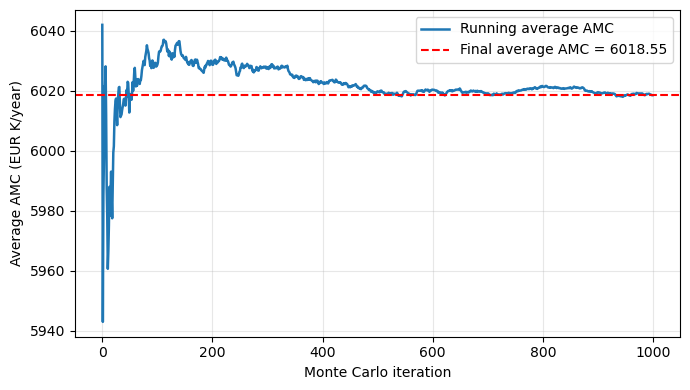

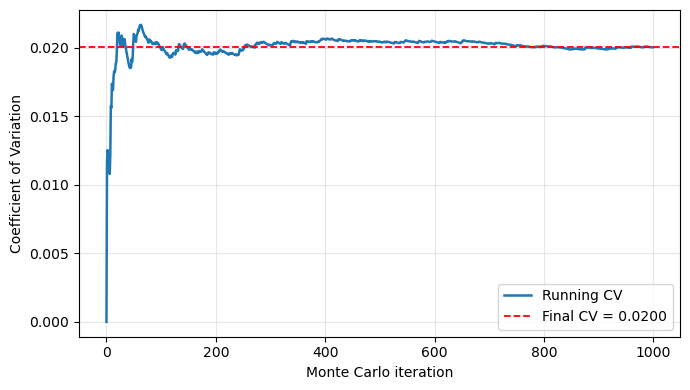

In [44]:
    # --- Simulation classes ---
    class Component:
        def __init__(self, name, id, age=0):
            self.name = name
            self.id = id
            self.age = age
            self.replaced = False
            self.shape = WEIBULL_PARAMS[name]['shape']
            self.scale = WEIBULL_PARAMS[name]['scale']
            self.failtime = np.random.weibull(self.shape) * self.scale

        def replace(self, day, replacements):
            self.age = 0
            self.failtime = day + np.random.weibull(self.shape) * self.scale
            self.replaced = True
            replacements[self.name] += 1
            cost = C1[self.name]
            return cost

        def minor_repair(self, day, minor_counts):
            self.age *= (1 - AGE_REDUCTION["minor"])
            u = np.random.random()
            remaining = (self.age**self.shape - (self.scale**self.shape) * np.log(u))**(1/self.shape) - self.age
            self.failtime = day + remaining
            minor_counts[self.name] += 1
            cost = C2[self.name]
            return cost

        def major_repair(self, day, major_counts):
            age_decrease = self.age*(1 - AGE_REDUCTION["major"])
            self.age -= age_decrease
            u = np.random.random()
            remaining = (self.age**self.shape - (self.scale**self.shape) * np.log(u))**(1/self.shape) - self.age
            self.failtime = day + remaining
            major_counts[self.name] += 1
            cost = C2[self.name]*(age_decrease**2)
            return cost
    class Turbine:
        def __init__(self, id):
            self.id = id
            self.components = [Component(name, id) for name in COMPONENTS]

    # --- Strategy function ---
    def strategy2(cycle_length):
        months = int(cycle_length / 30.416)
        strategy_name = f"TIME-BASED MAINTENANCE (TBM) EVERY {months} MONTHS"
        turbines = [Turbine(i) for i in range(N_TURBINES)]
        all_components = [comp for turb in turbines for comp in turb.components]
        maintenance_events = []
        for i in range(1, N_CYCLES):
            maintenance_events.append(cycle_length*i)
            

        minor_counts = {c: 0 for c in COMPONENTS}
        major_counts = {c: 0 for c in COMPONENTS}
        replacements = {c: 0 for c in COMPONENTS}
        day = 0
        total_cost = 0

        # Advance to first event
        next_maintenance = maintenance_events[0] if maintenance_events else float("inf")
        next_failure = min(comp.failtime for comp in all_components) if all_components else float("inf")
        day = min(next_failure, next_maintenance)

        for comp in all_components:
            comp.age += day

        while day <= (N_CYCLES+1) * cycle_length:
            daily_cost = 0
            maintenance = False
            serviced_turbines = set()

            next_maintenance = maintenance_events[0] if maintenance_events else float("inf")
            next_failure = min(comp.failtime for comp in all_components) if all_components else float("inf")

            while day >= min(next_failure, next_maintenance):
                # Handle failure events
                for comp in all_components:
                    if abs(comp.failtime - day) < 1e-6:  # handle float rounding
                        maintenance = True
                        serviced_turbines.add(comp.id)
                        daily_cost += comp.replace(day, replacements)
                # Handle scheduled maintenance
                if abs(day - next_maintenance) < 1e-6:
                    maintenance = True
                    for turb in turbines:
                        serviced_turbines.add(turb.id)
                        for comp in turb.components:
                            if not comp.replaced:
                                daily_cost += comp.minor_repair(day, minor_counts)
                            else:
                                comp.replaced = False
                    maintenance_events.pop(0)
                    next_maintenance = maintenance_events[0] if maintenance_events else float("inf")
                next_failure = min(comp.failtime for comp in all_components) if all_components else float("inf")

            # Add fixed costs
            daily_cost += maintenance * C_FIXED
            daily_cost += len(serviced_turbines) * C_ACCESS
            total_cost += daily_cost

            # Jump to next event
            next_day = min(next_failure, next_maintenance)
            delta = next_day - day
            if delta <= 0:
                delta = 1e-6  # avoid zero increment
            day = next_day
            # Update component ages
            for comp in all_components:
                comp.age += delta

            AMC = total_cost / day * 365

        return strategy_name, total_cost, day, AMC, replacements, minor_counts, major_counts

    # Run Monte Carlo
    run_simple_montecarlo(lambda: strategy2(365))

#### Strategy 3

TIME-BASED MAINTENANCE (TBM) EVERY 24 MONTHS
Iterations: 1000, Cycles per iteration: 10, Turbines: 50
Average total cost over 10 cycles: 107474.84 EUR $
Average total elapsed days for 10 cycles: 8042.8 days
Average AMC (per formula): 4877.45 K EUR/year (std: 87.81)

Average number of failure replacements over 10 cycles (by component):
 rotor    : 81.498
 bearing  : 71.700
 gearbox  : 121.348
 generator: 87.985

Average number of minor repairs over 10 cycles (by component):
 rotor    : 390.582
 bearing  : 395.815
 gearbox  : 359.191
 generator: 383.081

Average number of major repairs over 10 cycles (by component):
 rotor    : 0.000
 bearing  : 0.000
 gearbox  : 0.000
 generator: 0.000


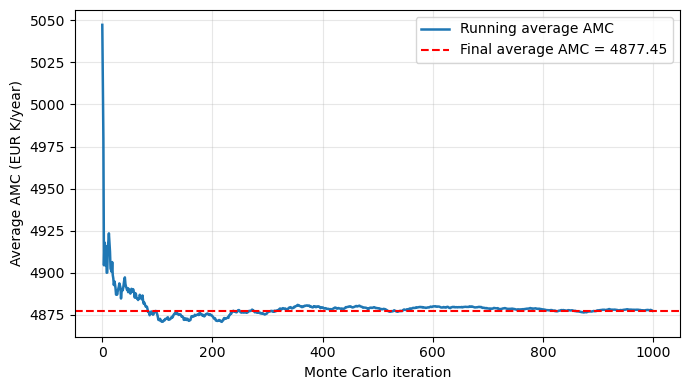

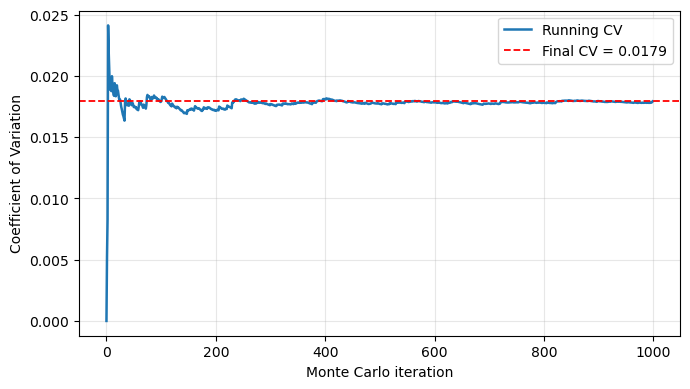

In [45]:
run_simple_montecarlo(lambda: strategy2(730))

#### Strategy 4

/Users/benrider/NewTILPythonEnv/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/benrider/NewTILPythonEnv/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


CORRECTIVE MAINTENANCE (CM)
Iterations: 1000, Cycles per iteration: 10, Turbines: 50
Average total cost over 10 cycles: 37568.96 EUR $
Average total elapsed days for 10 cycles: 4028.2 days
Average AMC (per formula): 3404.18 K EUR/year (std: 124.81)

Average number of failure replacements over 10 cycles (by component):
 rotor    : 54.143
 bearing  : 41.999
 gearbox  : 71.681
 generator: 50.126

Average number of minor repairs over 10 cycles (by component):
 rotor    : 0.000
 bearing  : 0.000
 gearbox  : 0.000
 generator: 0.000

Average number of major repairs over 10 cycles (by component):
 rotor    : 0.000
 bearing  : 0.000
 gearbox  : 0.000
 generator: 0.000


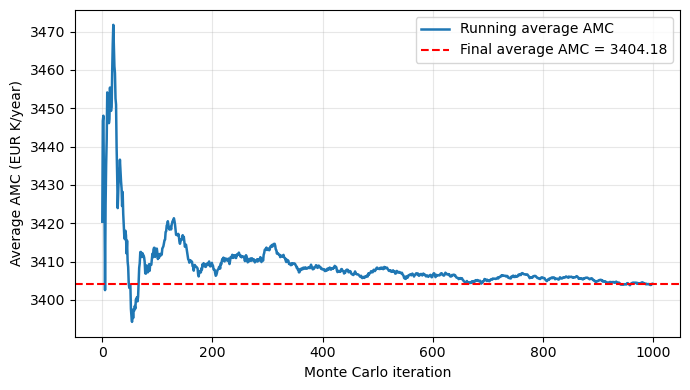

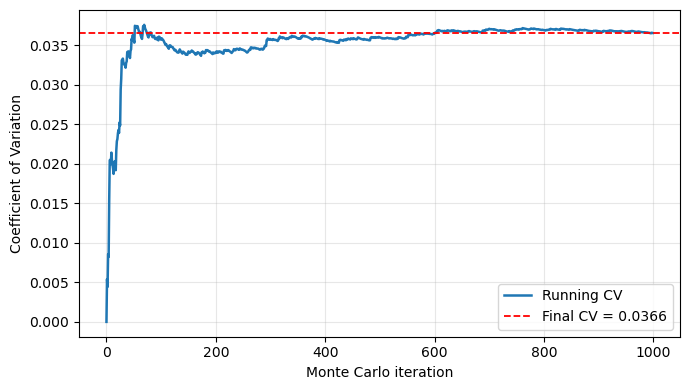

In [42]:
# --- Simulation classes ---
class Component:
    def __init__(self, name, id, age=0):
        self.name = name
        self.id = id
        self.age = age
        self.replaced = False
        self.shape = WEIBULL_PARAMS[name]['shape']
        self.scale = WEIBULL_PARAMS[name]['scale']
        self.failtime = np.random.weibull(self.shape) * self.scale
        self.MTTF = WEIBULL_PARAMS[name]['MTTF']

    def replace(self, day, replacements):
        self.age = 0
        self.failtime = day + np.random.weibull(self.shape) * self.scale
        self.replaced = True
        replacements[self.name] += 1

    def minor_repair(self, day, minor_counts):
        self.age *= (1 - AGE_REDUCTION["minor"])
        u = np.random.random()
        remaining = (self.age**self.shape - (self.scale**self.shape) * np.log(u))**(1/self.shape) - self.age
        self.failtime = day + remaining
        minor_counts[self.name] += 1

    def major_repair(self, day, major_counts):
        self.age *= (1 - AGE_REDUCTION["major"])
        u = np.random.random()
        remaining = (self.age**self.shape - (self.scale**self.shape) * np.log(u))**(1/self.shape) - self.age
        self.failtime = day + remaining
        major_counts[self.name] += 1

class Turbine:
    def __init__(self, id):
        self.id = id
        self.components = [Component(name, id) for name in COMPONENTS]

# --- Strategy function ---
def strategy4(cycle_length):
    strategy_name = "CONDITION BASED MAINTENANCE (CBM)"

    turbines = [Turbine(i) for i in range(N_TURBINES)]
    all_components = [comp for turb in turbines for comp in turb.components]  # flat list
        

    minor_counts = {c: 0 for c in COMPONENTS}
    major_counts = {c: 0 for c in COMPONENTS}
    replacements = {c: 0 for c in COMPONENTS}
    day = 0
    total_cost = 0

    # Advance to first event
    next_failure = min(comp.failtime for comp in all_components) if all_components else float("inf")
    day = next_failure

    for comp in all_components:
        comp.age += day

    while day <= (N_CYCLES+1) * cycle_length:
        daily_cost = 0
        maintenance = False
        serviced_turbines = set()
        while day >= next_failure:
            # Handle failure events
            for comp in all_components:
                if abs(comp.failtime - day) < 1e-6 or comp.age>= MAX_AGE*comp.MTTF:  # handle float rounding
                    maintenance = True
                    serviced_turbines.add(comp.id)
                    daily_cost += comp.replace(day, replacements)
                elif comp.age >= MED_AGE*comp.MTTF:
                    maintenance = True
                    serviced_turbines.add(comp.id)
                    daily_cost += comp.major_repair(day, major_counts)
                elif comp.age >= MIN_AGE*comp.MTTF:
                    maintenance = True
                    serviced_turbines.add(comp.id)
                    daily_cost += comp.minor_repair(day, minor_counts)
            next_failure = min(comp.failtime for comp in all_components) if all_components else float("inf")

        # Add fixed costs
        daily_cost += maintenance * C_FIXED
        daily_cost += len(serviced_turbines) * C_ACCESS
        total_cost += daily_cost

        # Jump to next event
        next_day = next_failure
        delta = next_day - day
        if delta <= 0:
            delta = 1e-6  # avoid zero increment
        day = next_day

        # Update component ages
        for comp in all_components:
            comp.age += delta

    AMC = total_cost / day * 365

    return strategy_name, total_cost, day, AMC, replacements, minor_counts, major_counts

# Run Monte Carlo
run_simple_montecarlo(lambda: strategy1(365))

### Analysis